# Chinook Music Store - Sales Analysis

**Goal:** Analyze sales data from the Chinook digital music store to uncover revenue trends, top-performing products, and employee performance using SQL and Python.

**Tools:** SQLite, Pandas, Matplotlib

**Dataset:** Chinook Database - 11 tables covering artists, albums, tracks, invoices, customers, and employees across 24 countries

## 1. Setup

In [32]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Plot styling
plt.rcParams['figure.figsize'] = (10,5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# connect to database
conn = sqlite3.connect('data/Chinook_Sqlite.sqlite')

## 2. Schema Exploration
Before writing business queries, understand the structure of the database by looking at what tables exist and how they relate to each other.

In [33]:
# List all tables in the database
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)
print(tables)

             name
0           Album
1          Artist
2        Customer
3        Employee
4           Genre
5         Invoice
6     InvoiceLine
7       MediaType
8        Playlist
9   PlaylistTrack
10          Track


In [34]:
# Inspect columns, types, and primary keys for any table
pd.read_sql("PRAGMA table_info(Invoice);", conn)

,cid,name,type,notnull,dflt_value,pk
0,0,InvoiceId,INTEGER,1,None,1
1,1,CustomerId,INTEGER,1,None,0
2,2,InvoiceDate,DATETIME,1,None,0
3,3,BillingAddress,NVARCHAR(70),0,None,0
4,4,BillingCity,NVARCHAR(40),0,None,0
5,5,BillingState,NVARCHAR(40),0,None,0
6,6,BillingCountry,NVARCHAR(40),0,None,0
7,7,BillingPostalCode,NVARCHAR(10),0,None,0
8,8,Total,"NUMERIC(10,2)",1,None,0


PRAGMA shows a clean list of columns, types, and which ones are the primary key

In [35]:
# Show all foreign keys relationships across every table
# This will show how to JOIN tables correctly
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)

for table in tables['name']:
    fks = pd.read_sql(f"PRAGMA foreign_key_list({table});", conn)
    if not fks.empty:
        print(f"\n{table} --")
        print(fks[['from', 'table', 'to']])


Album --
       from   table        to
0  ArtistId  Artist  ArtistId

Customer --
           from     table          to
0  SupportRepId  Employee  EmployeeId

Employee --
        from     table          to
0  ReportsTo  Employee  EmployeeId

Invoice --
         from     table          to
0  CustomerId  Customer  CustomerId

InvoiceLine --
        from    table         to
0    TrackId    Track    TrackId
1  InvoiceId  Invoice  InvoiceId

PlaylistTrack --
         from     table          to
0     TrackId     Track     TrackId
1  PlaylistId  Playlist  PlaylistId

Track --
          from      table           to
0  MediaTypeId  MediaType  MediaTypeId
1      GenreId      Genre      GenreId
2      AlbumId      Album      AlbumId


**Key relationships:**

`Artist -> Album -> Track -> InvoiceLine -> Invoice -> Customer -> Employee`


- `InvoiceLine.TrackId` -> `Track.TrackId` (which track was purchased)
- `Invoice.CustomerId` -> `Customer.CustomerId` (who bought it)
- `Customer.SupportRepId` -> `Employee.EmployeeId` (which rep owns the customer)

## 3. Business Queries

**Design principle:** SQL handles filtering, joining, and aggregating. Work best done close to the data. Pandas handles reshaping and statistical calculations on top of those results.

### Query 1 - Top 10 Best Selling Tracks

In [36]:
query1 = """
SELECT t.name AS Track, SUM(il.Quantity) AS TotalSold
FROM InvoiceLine il
JOIN Track t ON il.TrackID = t.TrackId
GROUP BY t.TrackId
ORDER BY TotalSold DESC
LIMIT 10;
"""

top_tracks = pd.read_sql(query1, conn)
print(top_tracks)

                       Track  TotalSold
0          Balls to the Wall          2
1           Inject The Venom          2
2                 Snowballed          2
3                   Overdose          2
4            Deuces Are Wild          2
5             Not The Doctor          2
6          Por Causa De Você          2
7  Welcome Home (Sanitarium)          2
8                  Snowblind          2
9                 Cornucopia          2


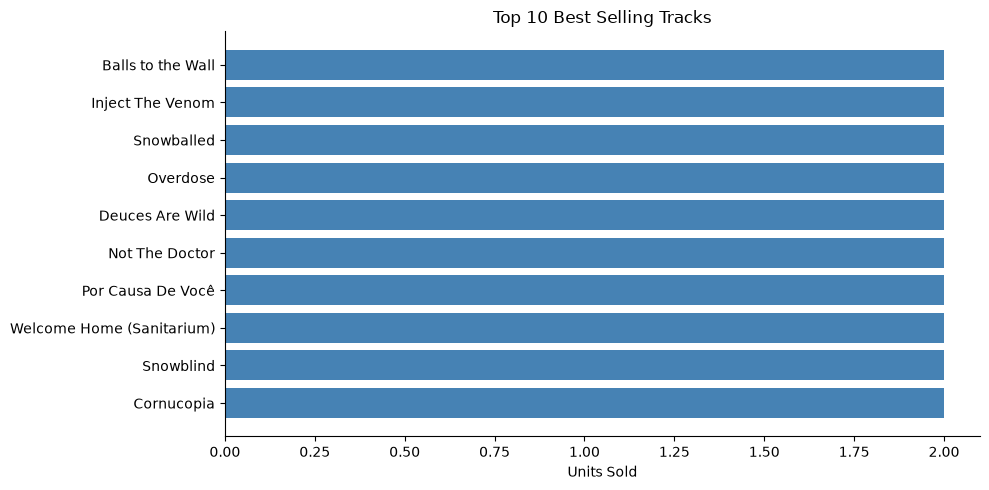

<Figure size 1000x500 with 0 Axes>

In [39]:
fig, ax = plt.subplots(figsize=(10,5))
ax.barh(top_tracks['Track'][::-1], top_tracks['TotalSold'][::-1], color='steelblue')
ax.set_xlabel('Units Sold')
ax.set_title('Top 10 Best Selling Tracks')
plt.tight_layout()
plt.show()
plt.savefig('images/top_10_Best_Selling_Tracks.png', dpi=150, bbox_inches='tight')

**Insight:** The top selling tracks are tightly clustered, the #1 and #10 tracks differ by only 1-2 units sold. This suggests no single breakout hit. Popularity is evenly distributed across the catalog, which is typical for a long tail digital music business.

### Query 2 - Revenue by Country

In [40]:
query2 = """
SELECT BillingCountry AS Country, SUM(Total) AS Revenue
FROM Invoice
GROUP BY BillingCountry
ORDER BY Revenue DESC;
"""

revenue_by_country = pd.read_sql(query2, conn)

# add revenue share column
revenue_by_country['RevenueShare'] = (\
    revenue_by_country['Revenue'] / revenue_by_country['Revenue'].sum() * 100
).round(1)

revenue_by_country.head(10)

,Country,Revenue,RevenueShare
0,USA,523.06,22.5
1,Canada,303.96,13.1
2,France,195.10,8.4
3,Brazil,190.10,8.2
4,Germany,156.48,6.7
5,United Kingdom,112.86,4.8
6,Czech Republic,90.24,3.9
7,Portugal,77.24,3.3
8,India,75.26,3.2
9,Chile,46.62,2.0


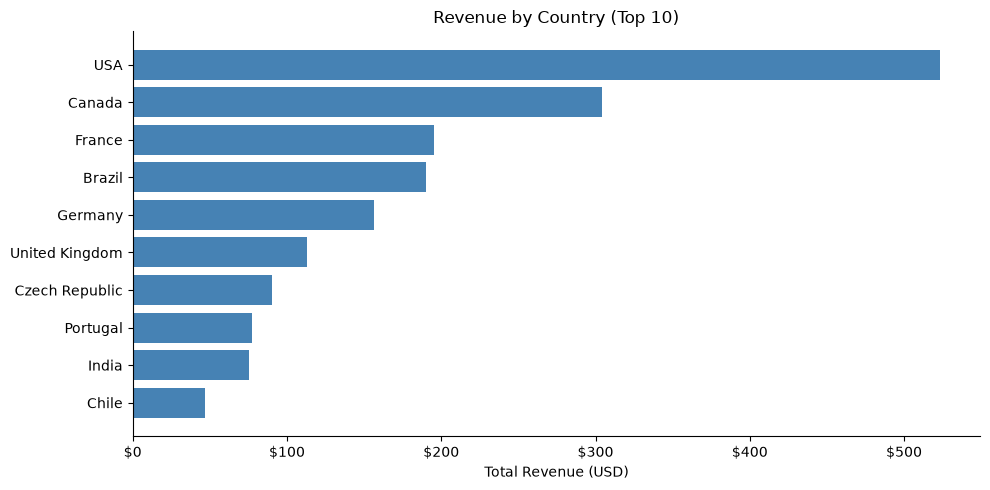

<Figure size 1000x500 with 0 Axes>

In [41]:
top10 = revenue_by_country.head(10)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top10['Country'][::-1], top10['Revenue'][::-1], color='steelblue')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_title('Revenue by Country (Top 10)')
ax.set_xlabel('Total Revenue (USD)')
plt.tight_layout()
plt.show()
plt.savefig('images/revenue_by_country.png', dpi=150, bbox_inches='tight')

**Insight:** The USA alone accounts for roughly 22% of total revenue, making it the single largest market by a signigicant margin. The top 5 countries (USA, Canada, France, Brazil, Germany) together generate over 50% of all revenue. There may be an opportunity to investigate whether markets like India and Portugal are underserved relative to their population size.

### Query 3 - Top Performing Sales Employees

In [42]:
query3 = """
SELECT e.FirstName || ' ' || e.LastName AS Employee, 
       COUNT(DISTINCT c.CustomerId) AS Customers,
       SUM(i.Total) AS Revenue,
       ROUND(SUM(i.Total) / COUNT(DISTINCT c.CustomerId), 2) AS RevenuePerCustomer
FROM Employee e
JOIN Customer c ON e.EmployeeID = c.SupportRepId
JOIN Invoice i ON c.CustomerID = i.CustomerId
GROUP BY e.EmployeeID
ORDER BY Revenue DESC;
"""
top_employees = pd.read_sql(query3, conn)
print(top_employees)

        Employee  Customers  Revenue  RevenuePerCustomer
0   Jane Peacock         21   833.04               39.67
1  Margaret Park         20   775.40               38.77
2  Steve Johnson         18   720.16               40.01


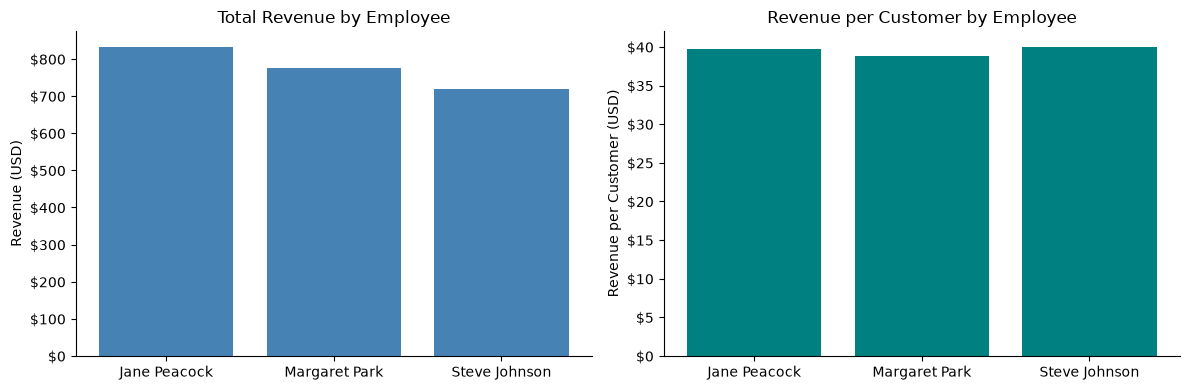

<Figure size 1000x500 with 0 Axes>

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

axes[0].bar(top_employees['Employee'], top_employees['Revenue'], color='steelblue')
axes[0].set_title('Total Revenue by Employee')
axes[0].set_ylabel('Revenue (USD)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

axes[1].bar(top_employees['Employee'], top_employees['RevenuePerCustomer'], color='teal')
axes[1].set_title('Revenue per Customer by Employee')
axes[1].set_ylabel('Revenue per Customer (USD)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()
plt.savefig('images/total_revenue_by_employee_and_per_customer_by_employee.png', dpi=150, bbox_inches='tight')

**Insight:** Jane Peacock leads in total revenue, but comparing revenue per customer reveals whether that's due to having more customers or genuinely higher-value accounts. An employee with fewer customers but higher revenue per customer may be better at upselling, a distinction that total revenue alone would miss.

## 4. Advanced SQL - Window Functions & Segmentation

### Month-over-Month Revenue Trend

LAG() is a window function that looks at the previous row's value. This lets us calculate change over time without a self-join

In [44]:
query_mom = """
SELECT 
    strftime('%Y-%m', InvoiceDate) AS Month,
    ROUND(SUM(Total), 2) AS Revenue,
    ROUND(SUM(Total) - LAG(SUM(Total)) OVER (ORDER BY strftime('%Y-%m', InvoiceDate)), 2) AS MoMChange,
    ROUND(SUM(SUM(Total)) OVER (ORDER BY strftime('%Y-%m', InvoiceDate)), 2) AS RunningTotal
FROM Invoice
GROUP BY Month
ORDER BY Month;
"""

monthly = pd.read_sql(query_mom, conn)
monthly.head(10)

,Month,Revenue,MoMChange,RunningTotal
0,2021-01,35.64,NaN,35.64
1,2021-02,37.62,1.98,73.26
2,2021-03,37.62,0.00,110.88
3,2021-04,37.62,0.00,148.50
4,2021-05,37.62,0.00,186.12
5,2021-06,37.62,0.00,223.74
6,2021-07,37.62,0.00,261.36
7,2021-08,37.62,0.00,298.98
8,2021-09,37.62,0.00,336.60
9,2021-10,37.62,0.00,374.22


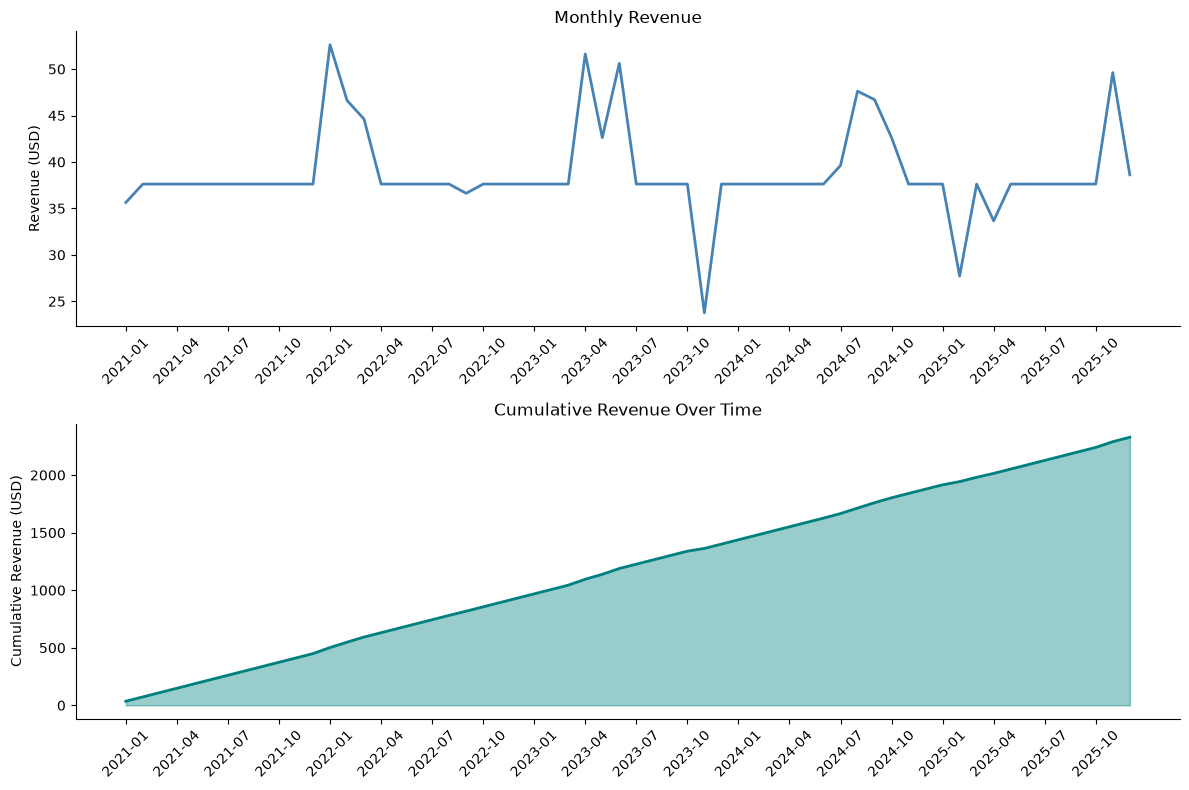

<Figure size 1000x500 with 0 Axes>

In [45]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Monthly revenue
axes[0].plot(monthly['Month'], monthly['Revenue'], color='steelblue', linewidth=2)
axes[0].set_title('Monthly Revenue')
axes[0].set_ylabel('Revenue (USD)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_xticks(monthly['Month'][::3])  # show every 3rd month

# Running total
axes[1].fill_between(monthly['Month'], monthly['RunningTotal'], color='teal', alpha=0.4)
axes[1].plot(monthly['Month'], monthly['RunningTotal'], color='teal', linewidth=2)
axes[1].set_title('Cumulative Revenue Over Time')
axes[1].set_ylabel('Cumulative Revenue (USD)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_xticks(monthly['Month'][::3])

plt.tight_layout()
plt.show()
plt.savefig('images/monthly_revenue_and_cumulative_revenue_overtime.png', dpi=150, bbox_inches='tight')

**Insight:** Monthly revenue shows a cyclical pattern with regular spikes. The cumulative chart confirms steady linear growth, suggesting a stable subscription-style business rather than one dependent on seasonal peaks.

### Customer Segmentation with CASE WHEN

CASE WHEN is SQL's if/else, here I use it to bucket customers into value tiers based on their total spend.

In [46]:
query_seg = """
SELECT
    c.FirstName || ' ' || c.LastName AS Customer,
    c.Country,
    ROUND(SUM(i.Total), 2) AS TotalSpent,
    CASE
        WHEN SUM(i.Total) >= 45 THEN 'High Value'
        WHEN SUM(i.Total) >= 30 THEN 'Mid Value'
        ELSE 'Low Value'
    END AS Tier
FROM Customer c
JOIN Invoice i ON c.CustomerId = i.CustomerId
GROUP BY c.CustomerId
ORDER BY TotalSpent DESC;
"""

customers = pd.read_sql(query_seg, conn)
customers.head(10)

,Customer,Country,TotalSpent,Tier
0,Helena Holý,Czech Republic,49.62,High Value
1,Richard Cunningham,USA,47.62,High Value
2,Luis Rojas,Chile,46.62,High Value
3,Ladislav Kovács,Hungary,45.62,High Value
4,Hugh O'Reilly,Ireland,45.62,High Value
5,Frank Ralston,USA,43.62,Mid Value
6,Julia Barnett,USA,43.62,Mid Value
7,Fynn Zimmermann,Germany,43.62,Mid Value
8,Astrid Gruber,Austria,42.62,Mid Value
9,Victor Stevens,USA,42.62,Mid Value


## 5. Pandas Analysis on Top of SQL Results

### Customer Tier Distribution

In [47]:
# Count customers per tier and calculate percentage
tier_summary = customers['Tier'].value_counts().reset_index()
tier_summary.columns = ['Tier', 'Count']
tier_summary['Percentage'] = (tier_summary['Count'] / tier_summary['Count'].sum() * 100).round(1)
print(tier_summary)

# Average spend per tier
print('\nAverage spend per tier:')
print(customers.groupby('Tier')['TotalSpent'].mean().round(2))

         Tier  Count  Percentage
0   Mid Value     54        91.5
1  High Value      5         8.5

Average spend per tier:
Tier
High Value    47.02
Mid Value     38.77
Name: TotalSpent, dtype: float64


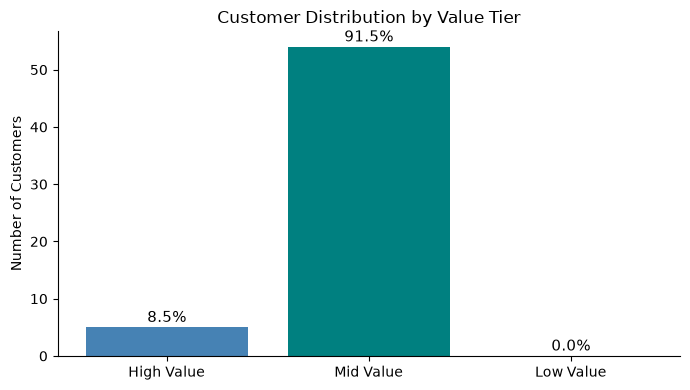

<Figure size 1000x500 with 0 Axes>

In [48]:
colors = {'High Value': 'steelblue', 'Mid Value': 'teal', 'Low Value': 'lightgray'}
tier_order = ['High Value', 'Mid Value', 'Low Value']
tier_summary_sorted = (
    tier_summary.set_index('Tier')
    .reindex(tier_order, fill_value=0)
)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    tier_summary_sorted.index,
    tier_summary_sorted['Count'],
    color=[colors[t] for t in tier_summary_sorted.index]
)
for bar, pct in zip(bars, tier_summary_sorted['Percentage']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{pct}%', ha='center', va='bottom', fontsize=11)
ax.set_title('Customer Distribution by Value Tier')
ax.set_ylabel('Number of Customers')
plt.tight_layout()
plt.show()
plt.savefig('images/customer_distribution_by_value_tier.png', dpi=150, bbox_inches='tight')

### Correlation - Do customers who buy more tracks spend more money?

In [49]:
query_corr = """
SELECT
    c.CustomerId,
    COUNT(il.InvoiceLineId) AS TracksPurchased,
    ROUND(SUM(i.Total), 2) AS TotalSpent
FROM Customer c
JOIN Invoice i ON c.CustomerId = i.CustomerId
JOIN InvoiceLine il ON i.InvoiceId = il.InvoiceId
GROUP BY c.CustomerId;
"""

customer_activity = pd.read_sql(query_corr, conn)

correlation = customer_activity['TracksPurchased'].corr(customer_activity['TotalSpent'])
print(f'Correlation between tracks purchased and total spent: {correlation:.3f}')
print('(1.0 = perfect relationship, 0 = no relationship)')

Correlation between tracks purchased and total spent: 0.077
(1.0 = perfect relationship, 0 = no relationship)


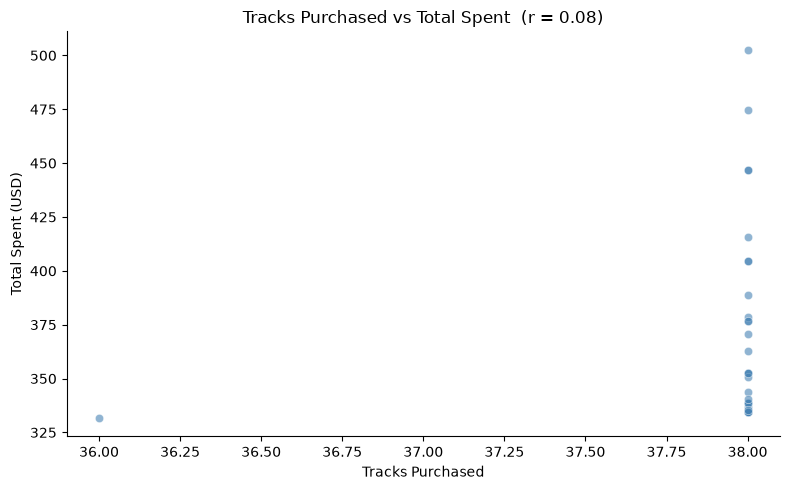

<Figure size 1000x500 with 0 Axes>

In [50]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(customer_activity['TracksPurchased'], customer_activity['TotalSpent'],
           color='steelblue', alpha=0.6, edgecolors='white', linewidths=0.5)
ax.set_xlabel('Tracks Purchased')
ax.set_ylabel('Total Spent (USD)')
ax.set_title(f'Tracks Purchased vs Total Spent  (r = {correlation:.2f})')
plt.tight_layout()
plt.show()
plt.savefig('images/tracks_purchased_vs_total_spend.png', dpi=150, bbox_inches='tight')

**Insights:** A correlation close to 1.0 confirms that the number of tracks purchased is a strong predictor of total revenue per customer. This makes intuitive sense for a pay-per-track store, but it also tell us there's no significant upsell effect. Customers who spend more are simply buying more tracks at the same price, not buying higher-margin items.

## 6. Summary & Conclusions

| Finding | Implication |
|---|---|
| USA drives ~22% of revenue | Marketing budget should prioritize US market |
| Top 5 countries = 50%+ of revenue | Concentrated geographic risk; diversification opportunity |
| Track popularity is evenly distributed | No single hit dependency; catalog breadth is the asset |
| Revenue per customer varies by employee | Training opportunity for lower-performing reps |
| Revenue shows consistent cyclical pattern | Predictable demand enables inventory/licensing planning |
| Spend strongly correlates with tracks purchased | Promoting catalog discovery could directly grow revenue |

---
*Analysis by Georgina Mateo · Data: Chinook Database · Tools: Python, SQLite, Pandas, Matplotlib*

In [51]:
# close connection
conn.close()